<a href="https://colab.research.google.com/github/HamzaEric/Protein_Localization_MLP/blob/main/Notebooks/Feed_Forward_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv("/content/drive/MyDrive/yeast.csv")
df.head()

,mcg,gvh,alm,mit,erl,pox,vac,nuc,localization_site
0,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


In [5]:
X = df.drop(columns=["localization_site"])
y = df["localization_site"]

In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [9]:
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
y_test = torch.tensor(y_test_np, dtype=torch.long)

# 7. Check dimensions
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Number of classes:", len(label_encoder.classes_))

Train set size: torch.Size([1187, 8])
Test set size: torch.Size([297, 8])
Number of classes: 10


In [10]:
df.columns

Index(['mcg', 'gvh', 'alm', 'mit', 'erl', 'pox', 'vac', 'nuc',
       'localization_site'],
      dtype='object')

In [12]:
print("X_train shape:", X_train)
print("X_test shape:", X_test)
print("y_train shape:", y_train)

CT_X_train shape: tensor([[-0.8023, -1.0488, -1.9625,  ..., -0.0991,  0.3481, -0.1522],
        [-1.3123,  1.4535,  0.1150,  ..., 10.8714,  0.8674, -0.5279],
        [ 0.5820,  0.2427, -1.9625,  ..., -0.0991,  0.1751, -0.5279],
        ...,
        [ 1.4563,  1.2114,  0.4613,  ..., -0.0991,  1.7328,  1.1629],
        [ 0.2905,  0.1620,  1.5001,  ..., -0.0991, -0.6903, -0.5279],
        [-0.5837, -1.0488,  1.0384,  ..., -0.0991,  0.3481,  0.1296]])
CT_X_test shape: tensor([[-3.6517e-01, -5.6451e-01,  1.1503e-01,  ..., -9.9131e-02,
          6.9430e-01,  5.0538e-01],
        [-1.4580e+00,  5.4395e-04, -1.8471e+00,  ..., -9.9131e-02,
          1.7506e-01, -5.2792e-01],
        [-2.9232e-01,  2.4271e-01, -3.4665e-01,  ..., -9.9131e-02,
          1.7506e-01,  7.8719e-01],
        ...,
        [-6.5661e-01, -3.2234e-01,  1.0384e+00,  ..., -9.9131e-02,
          1.3866e+00, -5.8236e-02],
        [ 7.2770e-01, -1.0488e+00,  2.3045e-01,  ..., -9.9131e-02,
          8.6738e-01, -1.5217e-01],
   

In [15]:
# Define the model using nn.Sequential
model = nn.Sequential(
    nn.Linear(8, 16),      # input layer to hidden layer
    nn.ReLU(),             # non-linearity
    nn.Linear(16, 10)      # hidden layer to output layer (10 classes)
)

print(model)

Sequential(
  (0): Linear(in_features=8, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
)


In [16]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 200
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    # Forward pass
    logits = model(X_train)
    loss = criterion(logits, y_train)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Record loss
    train_losses.append(loss.item())

    # Compute training accuracy
    preds = torch.argmax(logits, dim=1)
    correct = (preds == y_train).sum().item()
    accuracy = correct / len(y_train)
    train_accuracies.append(accuracy)

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}, Accuracy = {accuracy*100:.2f}%")


Epoch 10: Loss = 1.8502, Accuracy = 39.68%
Epoch 20: Loss = 1.4480, Accuracy = 52.49%
Epoch 30: Loss = 1.2276, Accuracy = 58.13%
Epoch 40: Loss = 1.1157, Accuracy = 60.24%
Epoch 50: Loss = 1.0622, Accuracy = 60.40%
Epoch 60: Loss = 1.0402, Accuracy = 60.40%
Epoch 70: Loss = 1.0263, Accuracy = 61.16%
Epoch 80: Loss = 1.0144, Accuracy = 61.67%
Epoch 90: Loss = 1.0049, Accuracy = 62.17%
Epoch 100: Loss = 0.9965, Accuracy = 62.51%
Epoch 110: Loss = 0.9888, Accuracy = 62.68%
Epoch 120: Loss = 0.9822, Accuracy = 62.59%
Epoch 130: Loss = 0.9766, Accuracy = 63.27%
Epoch 140: Loss = 0.9715, Accuracy = 63.52%
Epoch 150: Loss = 0.9660, Accuracy = 63.61%
Epoch 160: Loss = 0.9604, Accuracy = 63.77%
Epoch 170: Loss = 0.9548, Accuracy = 64.36%
Epoch 180: Loss = 0.9494, Accuracy = 64.62%
Epoch 190: Loss = 0.9448, Accuracy = 65.04%
Epoch 200: Loss = 0.9407, Accuracy = 65.12%


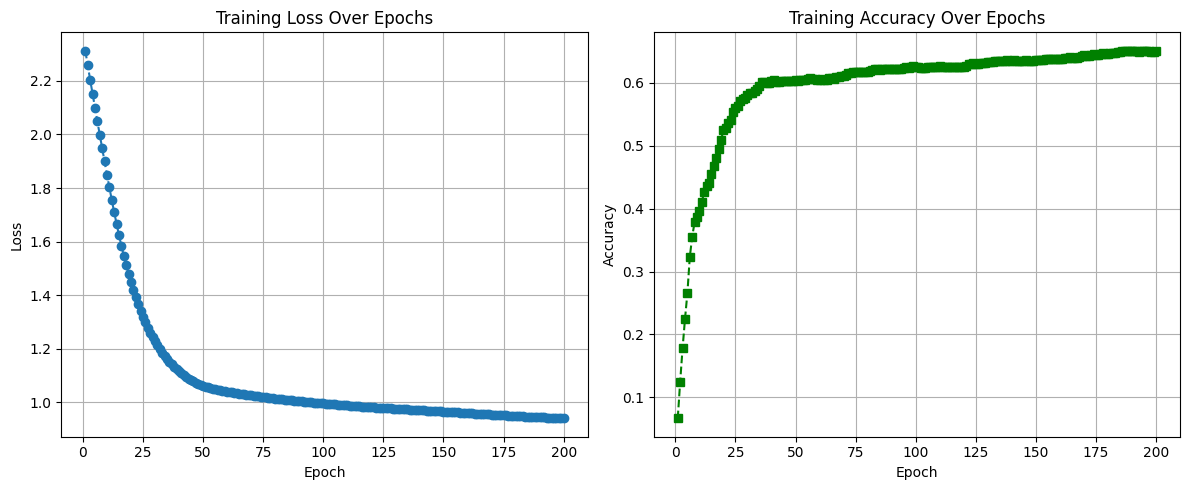

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', linestyle='--')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, marker='s', linestyle='--', color='green')
plt.title("Training Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

Test Accuracy: 0.5859


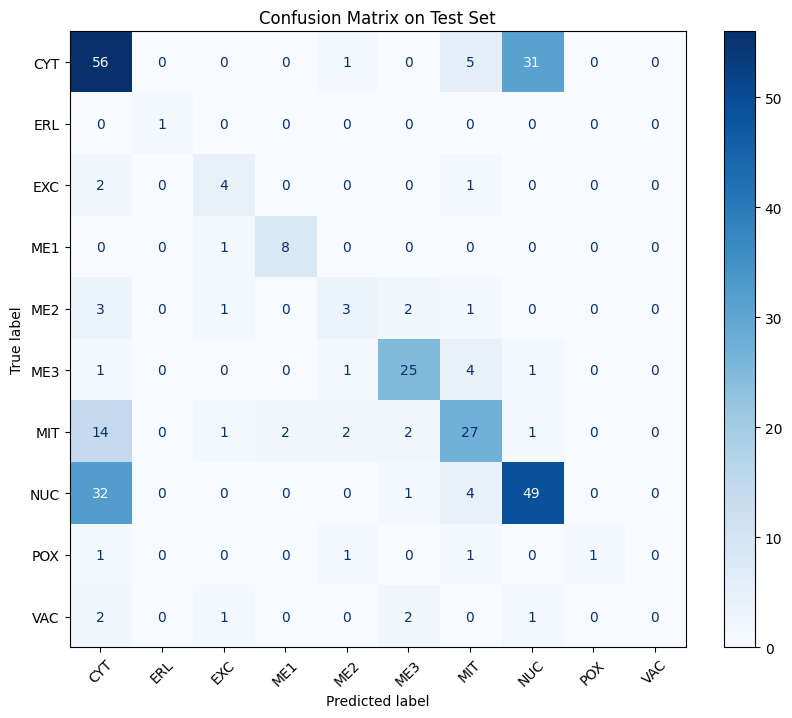

In [20]:
model.eval()

with torch.no_grad():
    y_pred_logits = model(X_test)
    y_pred_labels = torch.argmax(y_pred_logits, dim=1).cpu().numpy()

# ----- Convert ground truth to numpy -----
y_test_np = y_test.cpu().numpy()

# ----- Accuracy -----
acc = accuracy_score(y_test_np, y_pred_labels)
print(f"Test Accuracy: {acc:.4f}")

# ----- Confusion Matrix -----
cm = confusion_matrix(y_test_np, y_pred_labels)

# Assuming you used LabelEncoder before
from sklearn.preprocessing import LabelEncoder

# Re-create encoder and fit to original labels if needed
encoder = LabelEncoder()
encoder.fit(df['localization_site'])  # Ensure same order as before
class_names = encoder.classes_

# Display with class names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()
